In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
df=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
import matplotlib.pyplot as plt

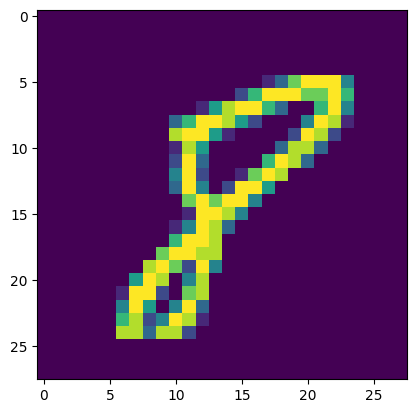

In [6]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

In [7]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
12486,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


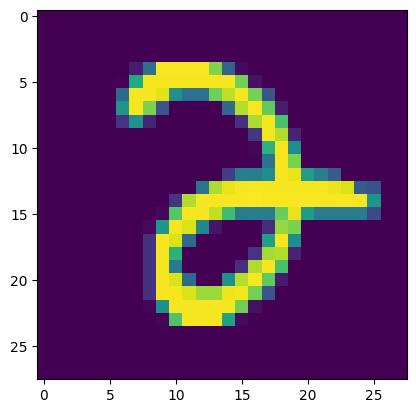

In [8]:
plt.imshow(df.iloc[8030,1:].values.reshape(28,28))

# Apply an Machine learning Model 

In [9]:
x=df.iloc[: ,1:]
y=df.iloc[:,0]

In [10]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
x_train.shape

(33600, 784)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
knn=KNeighborsClassifier()

In [14]:
knn.fit(x,y)

KNeighborsClassifier()

In [15]:
import time
start=time.time()
y_pred=knn.predict(x_test)
print(time.time()-start)

11.540282249450684


In [16]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9788095238095238


# PCA (Principle Component Analysis)

### first Apply StandardScaler (Mean Centered data)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
from sklearn.decomposition import PCA
pca=PCA(n_components=200)

In [19]:
x_train_trans = pca.fit_transform(x_train)
x_test_trans = pca.transform(x_test)

In [20]:
x_train_trans.shape

(33600, 200)

In [21]:
kn = KNeighborsClassifier()

In [22]:
kn.fit(x_train_trans,y_train)

KNeighborsClassifier()

In [23]:
y_pred = kn.predict(x_test_trans)

In [24]:
print (accuracy_score(y_test,y_pred))

0.9507142857142857


In [25]:


# for i in range(1,785):
#     pca=PCA(n_components=i)
#     x_train_trans = pca.fit_transform(x_train)
#     x_test_trans = pca.transform(x_test)

#     kn = KNeighborsClassifier()

#     kn.fit(x_train_trans,y_train)

#     y_pred = kn.predict(x_test_trans)

#     print (accuracy_score(y_test,y_pred))
    


## Visualizing the 784D data into 2D

In [26]:
pca=PCA(n_components=2)

x_train_tra = pca.fit_transform(x_train)
x_test_tra = pca.transform(x_test)

In [27]:
x_train_tra

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

### 784D data into the 2D using an PCA

In [28]:
import plotly.express as px

y_train_tra = y_train.astype(str)

fig = px.scatter(
    x=x_train_tra[:,0],
    y=x_train_tra[:,1],
    color=y_train_tra,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

## Using Scatter Plot

<Axes: >

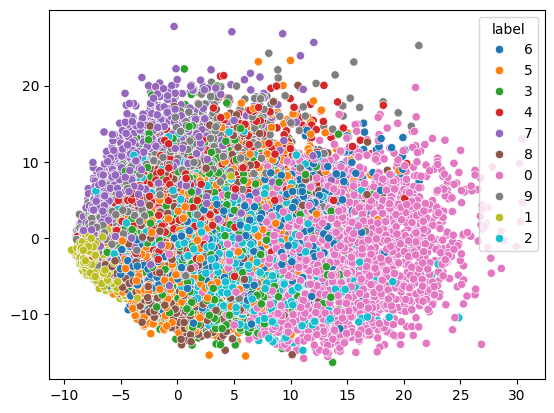

In [29]:
import seaborn as sns
y_train_tra = y_train.astype(str)
sns.scatterplot(x=x_train_tra[:,0],
    y=x_train_tra[:,1],
    hue=y_train_tra,)

## Visualization in 3D plane

In [30]:
pca = PCA(n_components=3)

x_train_tra = pca.fit_transform(x_train)

In [31]:
import plotly.express as px

y_train_tra = y_train.astype(str)

fig = px.scatter_3d(
    x=x_train_tra[:,0],
    y=x_train_tra[:,1],
    z=x_train_tra[:,2],
    color=y_train_tra,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()